In [2]:
import random
import pandas as pd
from ISLP.models import (ModelSpec as MS)
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

import seaborn as sns
from scipy import stats
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
from scipy.stats import gaussian_kde

In [3]:
random.seed(1234)

fashion_df = pd.read_csv("./data/fashion_data.csv")
fashion_df["Order Date"] = pd.to_datetime(fashion_df["Order Date"]) # Formating Order date back to Datetime dtype, in read_csv you cant set column to datetime so need to do manually
fashion_df.set_index("Order Date", inplace=True)
fashion_df.drop(columns=["Unnamed: 0"], inplace=True)


groceries_df = pd.read_csv("./data/grocery_data.csv")
groceries_df["Order Date"] = pd.to_datetime(groceries_df["Order Date"]) # Formating Order date back to Datetime dtype, in read_csv you cant set column to datetime so need to do manually
groceries_df.set_index("Order Date", inplace=True)
groceries_df.drop(columns=["Unnamed: 0"], inplace=True)

In [4]:
groceries_df.head()

,Shipping Address State,Revenue,Survey ResponseID,weather_category,age,race,education,income,gender,amazon_frequency,...,ratio_snacks_confectionery,ratio_specialty_health,day_of_the_week,Holiday,Season,ppt,tmax,tmin,tavg,Temp_No_Season
Order Date,,,,,,,,,,,,,,,,,,,,,
2017-01-01,AL,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,25.626,13.849,4.712,9.280,NaN
2017-01-01,AR,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.999,10.667,4.430,7.548,NaN
2017-01-01,AZ,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,4.824,9.969,4.154,7.061,NaN
2017-01-01,CA,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.760,9.559,0.137,4.848,NaN
2017-01-01,CO,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.385,2.787,-9.496,-3.354,NaN


# Definition Linear regression Function

In [5]:
def linear_reg_staates(data, var1, var2): 
    """ 
        var1: Is the first variable for the dependent variable of the linear regression
        var2: Is the second variable for the dependent variable of the linear regression
    """
    
    col = ["State", "Param_1", "P_value1", "Param_2", "P_value2", "R_sqrt"]
    results_lin_reg = pd.DataFrame(columns=col)
    
    states_list = fashion_df["Shipping Address State"].unique()
    

    for state in states_list: 
        df_one_state_filter = data["Shipping Address State"] == state
        df_one_state = data[df_one_state_filter].copy()


        # 365 days lagged temp column
        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(3)

        # 365 days lagged rain column
        df_one_state["Rain_No_Season"] = df_one_state["ppt"] - df_one_state["ppt"].shift(365)
        df_one_state["Rain_No_Season"] = df_one_state["Rain_No_Season"].round(3)

        # first order diff Revenue
        first_order_diff = [0]

        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])

        df_one_state["first_order_diff_Revenue"] = first_order_diff
        df_one_state["first_order_diff_Revenue"] = df_one_state["first_order_diff_Revenue"].round(4)

        # Lag first order diff Revenue 
        df_one_state.loc[:, "first_order_diff_Revenue_lagged"] = df_one_state["first_order_diff_Revenue"].shift(-1)

        # Lag revenue by 1 day
        df_one_state.loc[:, "Revenue_lagged"] = df_one_state["Revenue"].shift(-1)

        # Because of the one day shift we create a missing entry for the last day in or DF -> we fill this with 0
        df_one_state = df_one_state.fillna(0)

        # Calc SMA7 
        df_one_state.loc[:, "SMA7_ratio_hot"] = df_one_state["ratio_hot_weather"].rolling(7).mean().round(2)

        df_one_state.loc[:, "SMA7_ratio_cold"] = df_one_state["ratio_cold_weather"].rolling(7).mean().round(2)


        df_one_state.loc[:, "SMA7_ratio_cold_lagged"] = df_one_state["SMA7_ratio_cold"].shift(-1)
        df_one_state.loc[:, "SMA7_ratio_hot_lagged"] = df_one_state["SMA7_ratio_hot"].shift(-1)

        # Remove additional days for temp calculations
        df_one_state = df_one_state.iloc[365:, :]

        # Create linear time count 
        df_one_state.loc[:, 'Time'] = np.arange(len(df_one_state))
        df_one_state = df_one_state.fillna(0).infer_objects()

        x = MS(["tavg", "ppt"]).fit_transform(df_one_state)
        y = np.log(df_one_state[var1] * df_one_state[var2] + 1)
        model = sm.OLS(y, x)
        results = model.fit()

        #print(results.summary())

        next_idx = len(results_lin_reg)
        results_lin_reg.loc[next_idx] = [state, (results.params.iloc[1] * 100).round(3), results.pvalues.iloc[1].round(3), 
                        (results.params.iloc[2] * 100).round(3), results.pvalues.iloc[2].round(3), results.rsquared.round(3)]
        
        # Param 1 = tavg
        # Param 2 = ppt

    return results_lin_reg

1. SMA7_ratio_hot_weather_clothing * Revenue 
2. SMA7_ratio_cold_weather_clothing * Revenue 
3. SMA7_ratio_hot_weather_clothing * Revenue_lagged
3. SMA7_ratio_cold_weather * Revenue_lagged

In [6]:
fashion_hot_weather_rev = linear_reg_staates(fashion_df, "SMA7_ratio_hot_lagged", "Revenue_lagged")
fashion_cold_weather_rev = linear_reg_staates(fashion_df, "SMA7_ratio_cold_lagged", "Revenue_lagged")


groceries_hot_weather_rev = linear_reg_staates(groceries_df, "SMA7_ratio_hot_lagged", "Revenue_lagged")
groceries_cold_weather_rev = linear_reg_staates(groceries_df, "SMA7_ratio_cold_lagged", "Revenue_lagged")

C:\Users\Moritz\AppData\Local\Temp\ipykernel_3568\2183732832.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_one_state = df_one_state.fillna(0)
C:\Users\Moritz\AppData\Local\Temp\ipykernel_3568\2183732832.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_one_state = df_one_state.fillna(0)
C:\Users\Moritz\AppData\Local\Temp\ipykernel_3568\2183732832.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the

## Coefficient plot

In [7]:

def create_coefficient_boxplots(df_list, regression_names, param1_name='tavg', param2_name='ppt'):
    """
    Parameters:
    df_list: list of DataFrames, each containing regression results for one model
    regression_names: list of strings, names for each regression model
    param1_name: string, name of first parameter (default: 'tavg')
    param2_name: string, name of second parameter (default: 'ppt')
    """
    
    plt.style.use('seaborn-v0_8-whitegrid')
    n_models = len(df_list)
    
    # Create figure with two subplots side by side
    fig, (ax_tavg, ax_ppt) = plt.subplots(1, 2, figsize=(16, 8))
    
    colors = ['#2166ac', '#a6cee3', '#762a83', '#c2a5cf']
    positions = [-1, -0.7, -0.4, -0.1]  

    # Prepare data for boxplots
    tavg_data = []
    ppt_data = []
    
    for df in df_list:
        tavg_data.append(df['Param_1'].values)
        ppt_data.append(df['Param_2'].values)
    
    # Create tavg coefficient boxplot
    box1 = ax_tavg.boxplot(tavg_data, vert=False, patch_artist=True,
                           labels=regression_names, positions=positions, widths=0.25)
    
    for patch, color in zip(box1['boxes'], colors[:n_models]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    for element in ['whiskers', 'fliers', 'medians', 'caps']:
        for item in box1[element]:
            item.set_color('#08306b')
            item.set_linewidth(1.2)
    
    ax_tavg.set_xlabel(f'% change per °C', fontsize=12, fontweight='bold')
    ax_tavg.set_title(f'Average Temperature Coefficients Distribution', fontsize=14, fontweight='bold')
    ax_tavg.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=2)
    ax_tavg.tick_params(axis='y', rotation=0, labelsize=14)
    ax_tavg.xaxis.set_major_locator(MultipleLocator(1)) 
    ax_tavg.margins(x=0.05, y=0)
   
    
    # Create ppt coefficient boxplot
    box2 = ax_ppt.boxplot(ppt_data, vert=False, patch_artist=True, 
                        labels=[''] * len(ppt_data),  positions=positions, widths=0.25) # No labels for this boxplot
    
    for patch, color in zip(box2['boxes'], colors[:n_models]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    for element in ['whiskers', 'fliers', 'medians', 'caps']:
        for item in box2[element]:
            item.set_color('#08306b')
            item.set_linewidth(1.2)
    
    ax_ppt.set_xlabel(f'% change per mm', fontsize=12, fontweight='bold')
    ax_ppt.set_title(f'Rain Coefficients Distribution', fontsize=14, fontweight='bold')
    ax_ppt.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=2)
    ax_ppt.tick_params(axis='y')
    ax_ppt.xaxis.set_major_locator(MultipleLocator(1)) 
    
    fig.suptitle('Regression Coefficients Distribution Across US States', 
                fontsize=20, fontweight='bold', y=1)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    
    plt.savefig('./Exports/regression_coefficients_plot.png', dpi=300, bbox_inches='tight')
    
    return fig

C:\Users\Moritz\AppData\Local\Temp\ipykernel_3568\1942426280.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box1 = ax_tavg.boxplot(tavg_data, vert=False, patch_artist=True,
C:\Users\Moritz\AppData\Local\Temp\ipykernel_3568\1942426280.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box2 = ax_ppt.boxplot(ppt_data, vert=False, patch_artist=True,


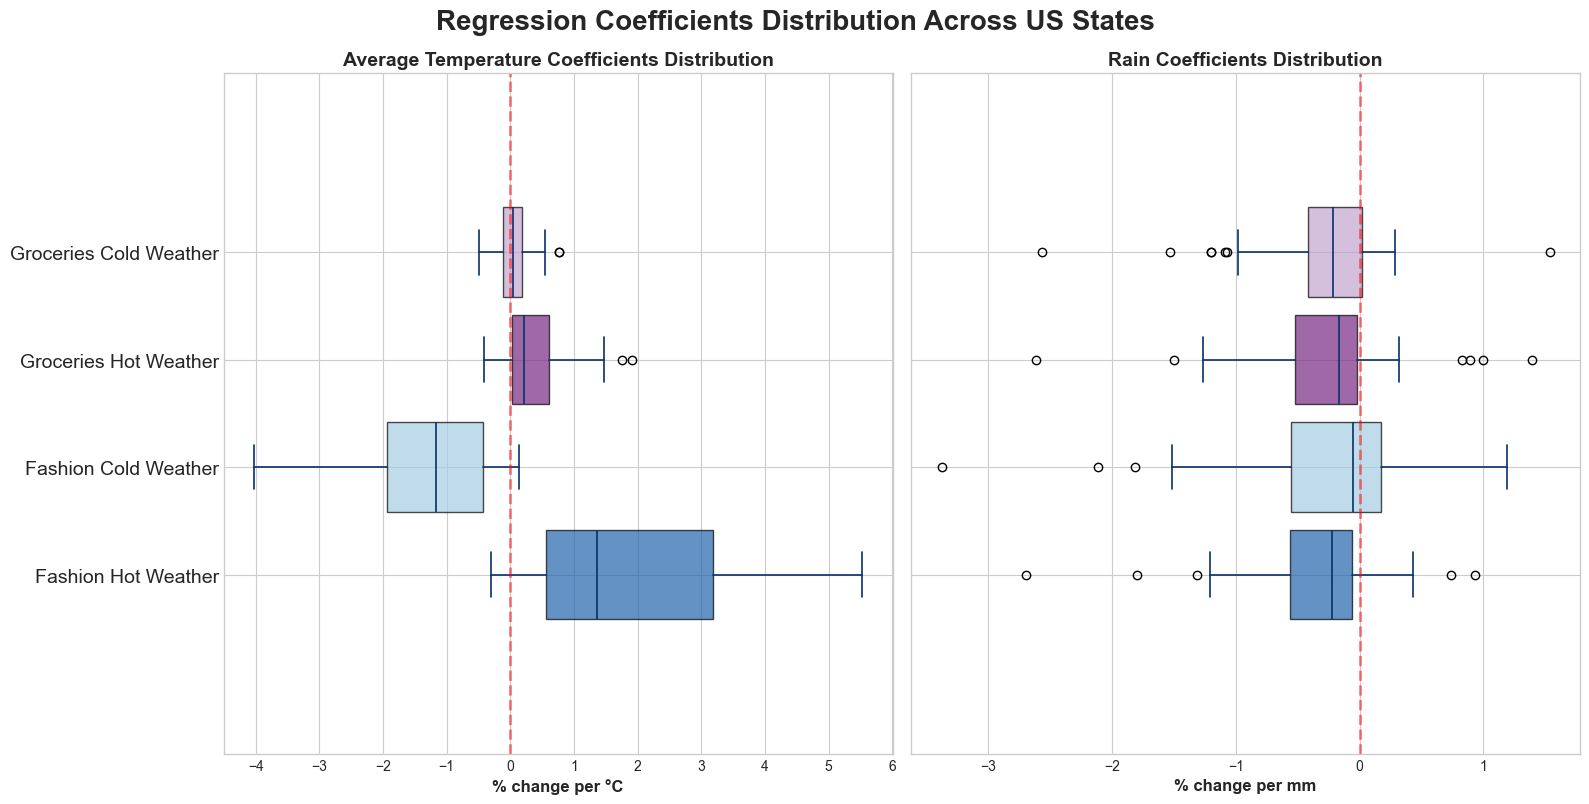

In [8]:
df_list = [fashion_hot_weather_rev, fashion_cold_weather_rev, groceries_hot_weather_rev, groceries_cold_weather_rev]
regression_names = ['Fashion Hot Weather', 'Fashion Cold Weather', 'Groceries Hot Weather', 'Groceries Cold Weather']
fig1 = create_coefficient_boxplots(df_list, regression_names)


## P-value plot

In [9]:
def create_pvalue_distributions(df_list, regression_names, param1_name='tavg', param2_name='ppt'):
    """
    Parameters:
    df_list: list of DataFrames, each containing regression results for one model
    regression_names: list of strings, names for each regression model
    param1_name: string, name of first parameter (default: 'tavg')
    param2_name: string, name of second parameter (default: 'ppt')
    """
    
    # Set up the figure with academic styling
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Create figure with two subplots side by side
    fig, (ax_tavg, ax_ppt) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Define color palette for each regression model (matching coefficient plots)
    colors = ['#2166ac', '#a6cee3', '#762a83', '#c2a5cf']
    line_styles = ['-', '-', '-.', '--']
    
    x_range = np.linspace(0, 1, 100)
    
    # Plot tavg p-value distributions
    for i, (df, name, color, linestyle) in enumerate(zip(df_list, regression_names, colors, line_styles)):
        p_values_tavg = df['P_value1'].values   
                 
        kde_tavg = gaussian_kde(p_values_tavg)
        density_tavg = kde_tavg(x_range)
        ax_tavg.plot(x_range, density_tavg, color=color, linewidth=2.5, 
                    alpha=0.8, label=name, linestyle=linestyle)
         
    
    ax_tavg.axvline(x=0.05, color='red', linestyle='--', alpha=0.7, linewidth=2, label='α = 0.05')
    ax_tavg.set_xlabel('P-values', fontsize=12, fontweight='bold')
    ax_tavg.set_ylabel('Frequency Density', fontsize=12, fontweight='bold')
    ax_tavg.set_title(f'P-value Distribution - Average Temperature', fontsize=14, fontweight='bold')
    ax_tavg.legend(fontsize=10, loc='upper right')
    ax_tavg.grid(True, alpha=0.3)
    ax_tavg.set_xlim(0, 1)
    
    # Plot ppt p-value distributions
    for i, (df, name, color, linestyle) in enumerate(zip(df_list, regression_names, colors, line_styles)):
        p_values_ppt = df['P_value2'].values
        kde_ppt = gaussian_kde(p_values_ppt)
        density_ppt = kde_ppt(x_range)
        ax_ppt.plot(x_range, density_ppt, color=color, linewidth=2.5, 
                    alpha=0.8, label=name, linestyle=linestyle)
            
    
    ax_ppt.axvline(x=0.05, color='red', linestyle='--', alpha=0.7, linewidth=2, label='α = 0.05')
    ax_ppt.set_xlabel('P-values', fontsize=12, fontweight='bold')
    ax_ppt.set_ylabel('Frequency Density', fontsize=12, fontweight='bold')
    ax_ppt.set_title(f'P-value Distribution - Precipitation', fontsize=14, fontweight='bold')
    ax_ppt.legend(fontsize=10, loc='upper right')
    ax_ppt.grid(True, alpha=0.3)
    ax_ppt.set_xlim(0, 1)
    
    fig.suptitle('P-value Distributions Across Regression Models', 
                fontsize=16, fontweight='bold', y=0.98)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.savefig('./Exports/regression_p_values.png', dpi=300, bbox_inches='tight')
    
    return fig

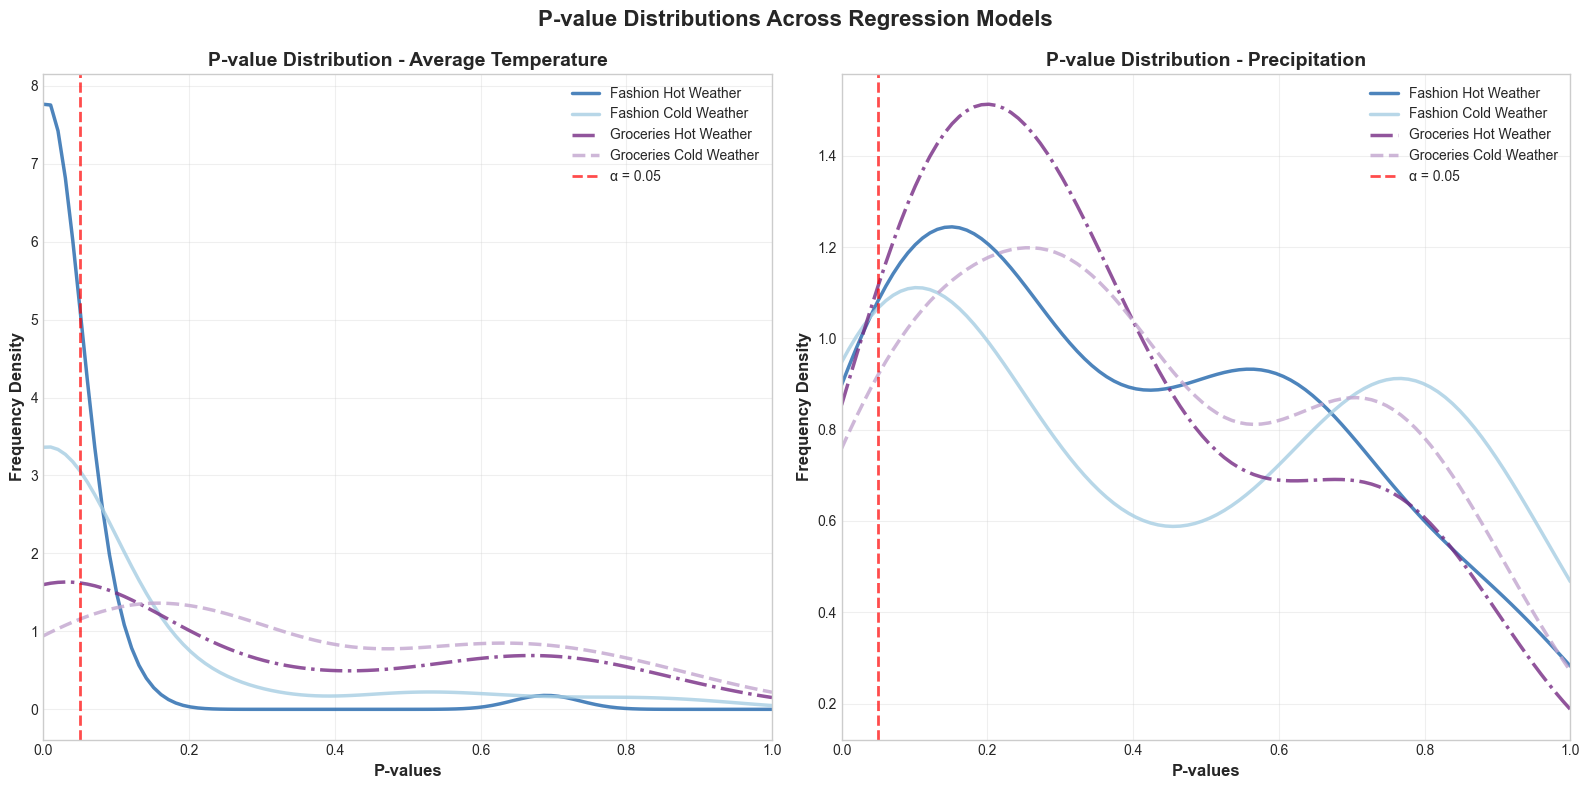

In [10]:
fig2 = create_pvalue_distributions(df_list, regression_names) 

## R^2 plot

In [11]:
def create_r_squared_boxplots(df_list, regression_names):
    """
    Parameters:
    df_list: list of DataFrames, each containing regression results for one model
    regression_names: list of strings, names for each regression model
    """
    
    plt.style.use('seaborn-v0_8-whitegrid')
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    colors = ['#2166ac', '#a6cee3', '#762a83', '#c2a5cf']
    
    # Prepare R2 data
    r2_data = []
    for df in df_list:
        r2_data.append(df['R_sqrt'].values)
    
    # Create boxplot
    box = ax.boxplot(r2_data, vert=True, patch_artist=True, widths=0.6,
                     labels=regression_names)
    
    for patch, color in zip(box['boxes'], colors[:len(df_list)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.2)
    
    for element in ['whiskers', 'fliers', 'medians', 'caps']:
        for item in box[element]:
            item.set_color('black')
            item.set_linewidth(1.5)
    
    ax.set_ylabel('R² Values', fontsize=14, fontweight='bold')
    ax.set_xlabel('Regression Models', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    
    ax.set_ylim(0, max([max(data) for data in r2_data]) * 1.1)
    
    # Optinal summary table
    """
    # Calculate mean R2 for each model
    mean_r2_values = []
    for df in df_list:
        r2_values = df['R_sqrt'].values
        mean_r2 = np.mean(r2_values)
        mean_r2_values.append(mean_r2)
    
    table_data = []
    for name, mean_r2 in zip(regression_names, mean_r2_values):
        table_data.append([name, f"{mean_r2:.4f}"])
    
    # Add table below the plot
    table = ax.table(cellText=table_data,
                    colLabels=['Model', 'Mean R²'],
                    cellLoc='center',
                    loc='bottom',
                    bbox=[0.2, -0.35, 0.6, 0.25])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 2)"""
  
    fig.suptitle('R² Distribution Across Regression Models', 
                fontsize=18, fontweight='bold', y=0.95)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, bottom=0.2)

    plt.savefig('./Exports/R2_values_regression.png', dpi=300, bbox_inches='tight')
    
    return fig

C:\Users\Moritz\AppData\Local\Temp\ipykernel_3568\2564299462.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(r2_data, vert=True, patch_artist=True, widths=0.6,


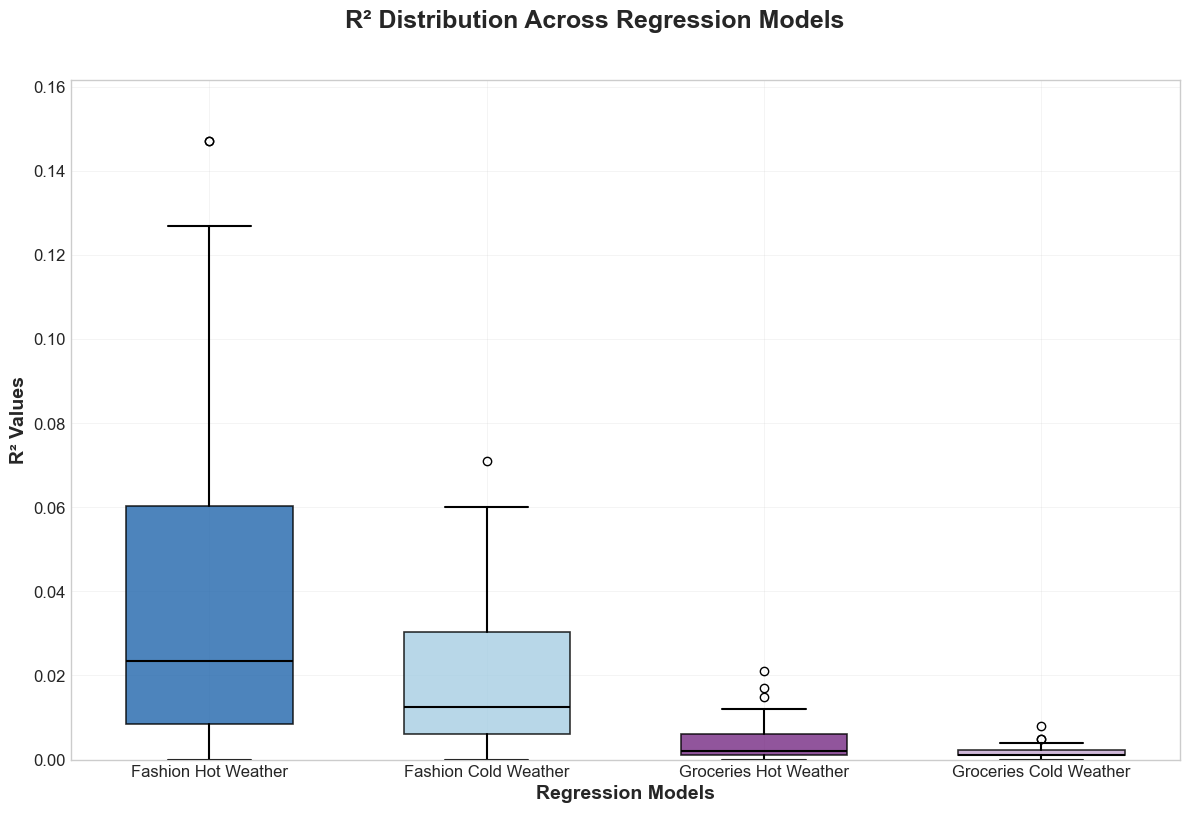

In [12]:
fig3 = create_r_squared_boxplots(df_list, regression_names)

# NOT YET DONE: Demographic Variables

In [13]:
"""from statsmodels.formula.api import ols

model = ols('SMA7_ratio_cold_weather_clothing ~ tavg + ppt  + C(age) + C(race) + C(education) + C(Season) + C(income) + C(gender) + C(amazon_frequency) + C(Holiday)', data=df_one_state)
fitted_model = model.fit()
fitted_model.summary()"""

"from statsmodels.formula.api import ols\n\nmodel = ols('SMA7_ratio_cold_weather_clothing ~ tavg + ppt  + C(age) + C(race) + C(education) + C(Season) + C(income) + C(gender) + C(amazon_frequency) + C(Holiday)', data=df_one_state)\nfitted_model = model.fit()\nfitted_model.summary()"

In [14]:
"""def linear_reg_staates(data, var1, var2): 
    col = ["State", "Param_1", "P_value1", "Param_2", "P_value2", "R_sqrt"]
    results_lin_reg = pd.DataFrame(columns=col)
    
    states_list = fashion_df["Shipping Address State"].unique()
    

    for state in states_list: 
        df_one_state_filter = data["Shipping Address State"] == state
        df_one_state = fashion_df[df_one_state_filter].copy()


        # 365 days lagged temp column
        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(3)

        # 365 days lagged rain column
        df_one_state["Rain_No_Season"] = df_one_state["ppt"] - df_one_state["ppt"].shift(365)
        df_one_state["Rain_No_Season"] = df_one_state["Rain_No_Season"].round(3)

        # first order diff Revenue
        first_order_diff = [0]

        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])

        df_one_state["first_order_diff_Revenue"] = first_order_diff
        df_one_state["first_order_diff_Revenue"] = df_one_state["first_order_diff_Revenue"].round(4)

        # Lag first order diff Revenue 
        df_one_state.loc[:, "first_order_diff_Revenue_lagged"] = df_one_state["first_order_diff_Revenue"].shift(-1)

        # Lag revenue by 1 day
        df_one_state.loc[:, "Revenue_lagged"] = df_one_state["Revenue"].shift(-1)

        # Because of the one day shift we create a missing entry for the last day in or DF -> we fill this with 0
        df_one_state = df_one_state.fillna(0)

        # Calc SMA7 
        df_one_state.loc[:, "SMA7_ratio_hot"] = df_one_state["ratio_hot_weather"].rolling(7).mean().round(2)

        df_one_state.loc[:, "SMA7_ratio_cold"] = df_one_state["ratio_cold_weather"].rolling(7).mean().round(2)


        df_one_state.loc[:, "SMA7_ratio_cold_lagged"] = df_one_state["SMA7_ratio_cold"].shift(-1)
        df_one_state.loc[:, "SMA7_ratio_hot_lagged"] = df_one_state["SMA7_ratio_hot"].shift(-1)

        # Remove additional days for temp calculations
        df_one_state = df_one_state.iloc[365:, :]

        # Create linear time count 
        df_one_state.loc[:, 'Time'] = np.arange(len(df_one_state))
        df_one_state = df_one_state.fillna(0).infer_objects()

        x = MS(["tavg", "ppt"]).fit_transform(df_one_state)
        y = np.log(df_one_state[var1] * df_one_state[var2] + 1)
        model = sm.OLS(y, x)
        results = model.fit()

        #print(results.summary())

        next_idx = len(results_lin_reg)
        results_lin_reg.loc[next_idx] = [state, (results.params.iloc[1] * 100).round(3), results.pvalues.iloc[1].round(3), 
                        (results.params.iloc[2] * 100).round(3), results.pvalues.iloc[2].round(3), results.rsquared.round(3)]
        
        # Param 1 = tavg
        # Param 2 = ppt

    return results_lin_reg"""

'def linear_reg_staates(data, var1, var2): \n    col = ["State", "Param_1", "P_value1", "Param_2", "P_value2", "R_sqrt"]\n    results_lin_reg = pd.DataFrame(columns=col)\n    \n    states_list = fashion_df["Shipping Address State"].unique()\n    \n\n    for state in states_list: \n        df_one_state_filter = data["Shipping Address State"] == state\n        df_one_state = fashion_df[df_one_state_filter].copy()\n\n\n        # 365 days lagged temp column\n        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)\n        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(3)\n\n        # 365 days lagged rain column\n        df_one_state["Rain_No_Season"] = df_one_state["ppt"] - df_one_state["ppt"].shift(365)\n        df_one_state["Rain_No_Season"] = df_one_state["Rain_No_Season"].round(3)\n\n        # first order diff Revenue\n        first_order_diff = [0]\n\n        for j in range(1,len(df_one_state)): \n            first_order_d

In [15]:
"""fashion_hot_weather_rev = linear_reg_staates(fashion_df, "SMA7_ratio_hot_lagged", "Revenue_lagged")"""

'fashion_hot_weather_rev = linear_reg_staates(fashion_df, "SMA7_ratio_hot_lagged", "Revenue_lagged")'